# Zadanie 2: Analiza tekstow medycznych (NER + klasyfikacja)

Ten notatnik jest napisany prostym jezykiem.
Cel: przejsc przez 4 etapy NLP i rozumiec, co robi kazda funkcja oraz jej parametry.

## Co tutaj zrobimy
1. Przygotowanie danych tekstowych.
2. Rozpoznawanie jednostek medycznych (NER).
3. Klasyfikacja dokumentow (to jest glowny punkt zadania).
4. Wizualizacja i krotkie wnioski.

## 0. Biblioteki i ustawienia

In [1]:
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

plt.rcParams['figure.figsize'] = (8, 4)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Srodowisko gotowe.')

Srodowisko gotowe.


## 1. Etap 1: Przygotowanie danych tekstowych

Ponizej sa funkcje z opisem parametrow:
- `csv_path`: sciezka do pliku z danymi (`text`, `label`).
- `n_samples`: ile tekstow wygenerowac, jesli nie ma pliku.
- `seed`: losowe ziarenko, aby wynik byl powtarzalny.

In [2]:
def generate_medical_texts(n_samples=40, seed=42):
    """
    Tworzy sztuczne (ale realistyczne) opisy medyczne.

    Parametry:
    - n_samples (int): liczba dokumentow do wygenerowania.
    - seed (int): steruje losowoscia, aby wyniki dalo sie odtworzyc.

    Zwraca:
    - DataFrame z kolumnami: text, label, source.
    """
    rnd = random.Random(seed)

    templates = {
        'cardio': [
            'Patient with chest pain, ECG changes and elevated troponin. Aspirin started.',
            'Hypertension poorly controlled. Add ACE inhibitor and monitor blood pressure.',
            'Suspected myocardial infarction, urgent cardiology consultation required.',
        ],
        'endo': [
            'Type 2 diabetes with HbA1c above target. Increase metformin dose and diet control.',
            'Hyperglycemia in morning profile. Consider basal insulin and glucose monitoring.',
            'Diabetic patient reports fatigue and polyuria. Check fasting glucose and HbA1c.',
        ],
        'resp': [
            'Cough and fever, CT suggests right lower lobe pneumonia. Start amoxicillin.',
            'Asthma exacerbation after infection, wheezing present. Inhaled steroids recommended.',
            'Dyspnea and productive cough. Chest imaging and antibiotic therapy planned.',
        ],
        'gastro': [
            'Melena with low hemoglobin, likely upper GI bleed. Endoscopy planned.',
            'Epigastric pain after NSAID use, possible gastric ulcer. PPI started.',
            'Nausea and abdominal pain, evaluate liver and pancreatic enzymes.',
        ],
    }

    labels = list(templates.keys())
    rows = []
    for _ in range(n_samples):
        label = rnd.choice(labels)
        text = rnd.choice(templates[label])
        rows.append({'text': text, 'label': label, 'source': 'synthetic'})

    return pd.DataFrame(rows)


def load_or_generate_data(csv_path='medical_texts.csv', n_samples=40, seed=42):
    """
    Laduje dane z CSV lub generuje je automatycznie.

    Parametry:
    - csv_path (str): plik z kolumnami text,label.
    - n_samples (int): liczba rekordow przy generowaniu.
    - seed (int): losowosc przy generowaniu.

    Zwraca:
    - DataFrame z kolumnami text,label,source.
    """
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        required = {'text', 'label'}
        if not required.issubset(df.columns):
            raise ValueError('CSV musi miec kolumny: text i label.')
        out = df[['text', 'label']].copy()
        out['source'] = 'csv'
        return out

    return generate_medical_texts(n_samples=n_samples, seed=seed)


df = load_or_generate_data(csv_path='medical_texts.csv', n_samples=60, seed=SEED)
print('Rozmiar danych:', df.shape)
print(df['label'].value_counts())
df.head()

Rozmiar danych: (60, 3)
label
resp      18
endo      17
cardio    13
gastro    12
Name: count, dtype: int64


,text,label,source
0,"Patient with chest pain, ECG changes and eleva...",cardio,synthetic
1,"Cough and fever, CT suggests right lower lobe ...",resp,synthetic
2,Type 2 diabetes with HbA1c above target. Incre...,endo,synthetic
3,"Suspected myocardial infarction, urgent cardio...",cardio,synthetic
4,"Suspected myocardial infarction, urgent cardio...",cardio,synthetic


### Uzycie Twojego pliku CSV

Ponizej nadpisujemy dane i bierzemy bezposrednio plik `variant_14_internal.csv`.

In [12]:
CSV_PATH = 'variant_14_internal.csv'
df = load_or_generate_data(csv_path=CSV_PATH, n_samples=60, seed=SEED)

print('Wczytano z:', CSV_PATH)
print('Rozmiar danych:', df.shape)
print(df['label'].value_counts())
df.head()

Wczytano z: variant_14_internal.csv
Rozmiar danych: (5, 3)
label
cardio       1
metabolic    1
renal        1
resp         1
hema         1
Name: count, dtype: int64


,text,label,source
0,Hypertension and hyperlipidemia under treatmen...,cardio,csv
1,Obesity with metabolic syndrome. HbA1c 6.8%. L...,metabolic,csv
2,Chronic kidney disease stage 3. Creatinine 2.0...,renal,csv
3,COPD stable on inhalers. FEV1 70% predicted. V...,resp,csv
4,Iron deficiency anemia. Ferritin 10 ng/mL. Ora...,hema,csv


In [13]:
def expand_if_too_small(df, min_per_class=4, seed=42):
    """
    Jesli klas jest za malo, tworzy lekkie parafrazy tekstu.

    Parametry:
    - df: dane z kolumnami text, label, source
    - min_per_class: minimalna liczba rekordow na klase
    - seed: losowosc

    Zwraca:
    - DataFrame (oryginal lub powiekszony)
    """
    rnd = random.Random(seed)
    prefixes = ['Clinical note:', 'Follow-up:', 'Assessment:', 'Medical report:']
    suffixes = [
        'Patient advised for control visit.',
        'Monitoring plan documented.',
        'Further evaluation recommended.',
        'Therapy compliance discussed.',
    ]

    parts = []
    for label, grp in df.groupby('label', as_index=False):
        grp = grp.copy()
        parts.append(grp)
        need = max(0, min_per_class - len(grp))

        base_texts = grp['text'].tolist()
        for i in range(need):
            base = base_texts[i % len(base_texts)]
            new_text = f"{rnd.choice(prefixes)} {base} {rnd.choice(suffixes)}"
            parts.append(pd.DataFrame([{
                'text': new_text,
                'label': label,
                'source': 'augmented_from_csv'
            }]))

    return pd.concat(parts, ignore_index=True)


min_count = df['label'].value_counts().min()
if min_count < 2:
    print('Uwaga: za malo probek na klase do rzetelnego podzialu train/test.')
    print('Automatycznie powiekszam dane przez proste parafrazy (wariant dydaktyczny).')
    df = expand_if_too_small(df, min_per_class=4, seed=SEED)

print('Nowy rozmiar danych:', df.shape)
print(df['label'].value_counts())

Uwaga: za malo probek na klase do rzetelnego podzialu train/test.
Automatycznie powiekszam dane przez proste parafrazy (wariant dydaktyczny).
Nowy rozmiar danych: (20, 3)
label
cardio       4
hema         4
metabolic    4
renal        4
resp         4
Name: count, dtype: int64


In [14]:
def clean_text(text, remove_numbers=True):
    """
    Czyści pojedynczy tekst.

    Parametry:
    - text (str): surowy tekst.
    - remove_numbers (bool): jesli True, usuwa liczby.

    Zwraca:
    - str: oczyszczony tekst.
    """
    text = text.lower()
    text = re.sub(r'https?://\S+', ' ', text)
    if remove_numbers:
        text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def simple_tokenize(text):
    """
    Dzieli tekst na slowa (tokeny).

    Parametry:
    - text (str): tekst po czyszczeniu.

    Zwraca:
    - list[str]: lista tokenow.
    """
    return text.split()


def simple_lemmatize_token(token):
    """
    Bardzo prosty lematyzator regulowy (edukacyjny).
    To nie zastepuje pelnego modelu NLP.
    """
    for suf in ['ing', 'ed', 'es', 's']:
        if token.endswith(suf) and len(token) > len(suf) + 2:
            return token[:-len(suf)]
    return token


def simple_lemmatize(tokens):
    """
    Lematizacja listy tokenow.

    Parametry:
    - tokens (list[str]): tokeny po tokenizacji.

    Zwraca:
    - list[str]: tokeny po uproszczonej lematyzacji.
    """
    return [simple_lemmatize_token(t) for t in tokens]


df['clean'] = df['text'].apply(clean_text)
df['tokens'] = df['clean'].apply(simple_tokenize)
df['lemmas'] = df['tokens'].apply(simple_lemmatize)

print('Przyklad po czyszczeniu:')
print(df.loc[0, 'clean'])
print('Tokeny:', df.loc[0, 'tokens'][:10])
print('Lematy:', df.loc[0, 'lemmas'][:10])

Przyklad po czyszczeniu:
hypertension and hyperlipidemia under treatment bp mmhg ldl mg dl
Tokeny: ['hypertension', 'and', 'hyperlipidemia', 'under', 'treatment', 'bp', 'mmhg', 'ldl', 'mg', 'dl']
Lematy: ['hypertension', 'and', 'hyperlipidemia', 'under', 'treatment', 'bp', 'mmhg', 'ldl', 'mg', 'dl']


## 2. Etap 2: Rozpoznawanie jednostek medycznych (NER)

Tu robimy prosty NER slownikowy (czyli szukamy znanych slow/fraz).
To podejscie jest dobre na start, bo latwo je zrozumiec i debugowac.

In [15]:
MEDICAL_LEXICON = {
    'DISEASE': [
        'diabetes', 'hypertension', 'pneumonia', 'asthma',
        'infarction', 'ulcer', 'hyperglycemia'
    ],
    'DRUG': [
        'aspirin', 'metformin', 'amoxicillin', 'insulin',
        'steroids', 'ppi', 'inhibitor'
    ],
    'TEST_OR_PROC': [
        'ecg', 'troponin', 'ct', 'endoscopy', 'monitoring', 'imaging'
    ]
}


def extract_entities(text, lexicon):
    """
    Wyszukuje encje slownikowo.

    Parametry:
    - text (str): pojedynczy tekst.
    - lexicon (dict): slownik etykieta -> lista fraz.

    Zwraca:
    - list[tuple(str, str)]: lista (encja, etykieta).
    """
    found = []
    for label, phrases in lexicon.items():
        for phrase in phrases:
            pattern = rf'\b{re.escape(phrase)}\b'
            if re.search(pattern, text):
                found.append((phrase, label))
    return found


df['entities'] = df['clean'].apply(lambda t: extract_entities(t, MEDICAL_LEXICON))

entity_counter = Counter()
for ents in df['entities']:
    entity_counter.update([e[0] for e in ents])

print('Top 10 encji:')
print(entity_counter.most_common(10))

df[['text', 'entities']].head(5)

Top 10 encji:
[('monitoring', 7), ('hypertension', 4), ('inhibitor', 4)]


,text,entities
0,Hypertension and hyperlipidemia under treatmen...,"[(hypertension, DISEASE)]"
1,Clinical note: Hypertension and hyperlipidemia...,"[(hypertension, DISEASE)]"
2,Assessment: Hypertension and hyperlipidemia un...,"[(hypertension, DISEASE), (monitoring, TEST_OR..."
3,Follow-up: Hypertension and hyperlipidemia und...,"[(hypertension, DISEASE), (monitoring, TEST_OR..."
4,Iron deficiency anemia. Ferritin 10 ng/mL. Ora...,[]


## 3. Etap 3: Klasyfikacja dokumentow (najwazniejsza czesc zadania)

W tym etapie komputer uczy sie zgadywac etykiete calego dokumentu.
Przetwarzamy tekst na liczby przez TF-IDF, potem uczymy model klasyfikacyjny.

Parametry, ktore warto rozumiec:
- `test_size`: jaka czesc danych idzie do testu (np. 0.3 = 30%).
- `random_state`: stala losowosc, by wynik byl powtarzalny.
- `model_name`: `logreg` albo `linearsvc`.
- `max_features`: ile cech tekstowych (najczestszych tokenow) bierzemy do modelu.

In [16]:
def train_text_classifier(df, model_name='logreg', test_size=0.3, random_state=42, max_features=2000):
    """
    Trenuje klasyfikator tekstu i zwraca wszystko do analizy.

    Parametry:
    - df (DataFrame): musi miec kolumny `clean` i `label`.
    - model_name (str): `logreg` lub `linearsvc`.
    - test_size (float): czesc danych na test.
    - random_state (int): kontrola losowosci.
    - max_features (int): maksymalna liczba cech TF-IDF.

    Zwraca:
    - dict: model, vectorizer, predykcje i metryki.
    """
    X = df['clean'].values
    y = df['label'].values

    value_counts = pd.Series(y).value_counts()
    use_stratify = not (value_counts < 2).any()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if use_stratify else None,
    )

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=max_features)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    if model_name == 'linearsvc':
        model = LinearSVC()
    else:
        model = LogisticRegression(max_iter=2000)

    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    acc = accuracy_score(y_test, y_pred)

    return {
        'model': model,
        'vectorizer': vectorizer,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred': y_pred,
        'accuracy': acc,
        'report_dict': report,
    }


result_logreg = train_text_classifier(df, model_name='logreg', test_size=0.3, random_state=SEED)
result_svc = train_text_classifier(df, model_name='linearsvc', test_size=0.3, random_state=SEED)

print('Accuracy LogisticRegression:', round(result_logreg['accuracy'], 3))
print('Accuracy LinearSVC:        ', round(result_svc['accuracy'], 3))

best_result = result_logreg if result_logreg['accuracy'] >= result_svc['accuracy'] else result_svc
best_name = 'LogisticRegression' if best_result is result_logreg else 'LinearSVC'
print('Wybrany model:', best_name)

report_df = pd.DataFrame(best_result['report_dict']).transpose()
report_df

Accuracy LogisticRegression: 1.0
Accuracy LinearSVC:         1.0
Wybrany model: LogisticRegression


,precision,recall,f1-score,support
cardio,1.0,1.0,1.0,1.0
hema,1.0,1.0,1.0,1.0
metabolic,1.0,1.0,1.0,1.0
renal,1.0,1.0,1.0,2.0
resp,1.0,1.0,1.0,1.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,6.0
weighted avg,1.0,1.0,1.0,6.0


## 4. Etap 4: Wizualizacja i interpretacja wynikow

Najpierw zaznaczymy encje w tekscie, potem narysujemy:
- czestosc encji,
- macierz pomylek dla najlepszego modelu.
Na koncu: krotkie wnioski.

Przyklady podswietlenia encji:
- [hypertension<DISEASE>] and hyperlipidemia under treatment bp mmhg ldl mg dl
- clinical note [hypertension<DISEASE>] and hyperlipidemia under treatment bp mmhg ldl mg dl patient advised for control visit
- assessment [hypertension<DISEASE>] and hyperlipidemia under treatment bp mmhg ldl mg dl [monitoring<TEST_OR_PROC>] plan documented


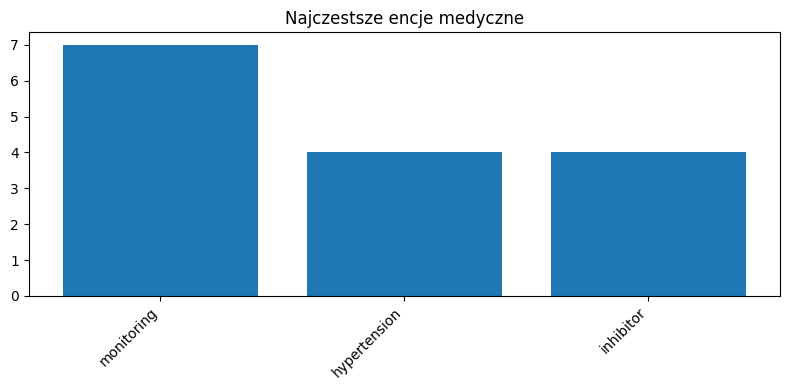

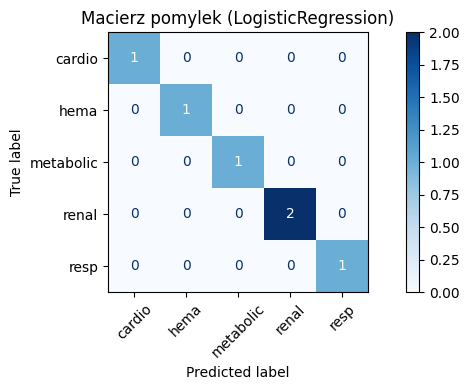

In [17]:
def highlight_entities(text, entities):
    """
    Podmienia fragmenty tekstu na format [encja<LABEL>].

    Parametry:
    - text (str): oryginalny tekst.
    - entities (list[tuple]): lista (encja, etykieta).

    Zwraca:
    - str: tekst z zaznaczeniem encji.
    """
    out = text
    for ent, label in sorted(entities, key=lambda x: len(x[0]), reverse=True):
        out = re.sub(rf'\b{re.escape(ent)}\b', f'[{ent}<{label}>]', out)
    return out


print('Przyklady podswietlenia encji:')
for i in range(min(3, len(df))):
    print('-', highlight_entities(df.loc[i, 'clean'], df.loc[i, 'entities']))

# Wykres czestosci encji
most_common = entity_counter.most_common(10)
if most_common:
    names = [x[0] for x in most_common]
    counts = [x[1] for x in most_common]
    plt.figure()
    plt.bar(names, counts)
    plt.title('Najczestsze encje medyczne')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Macierz pomylek najlepszego modelu
labels_sorted = sorted(df['label'].unique())
cm = confusion_matrix(best_result['y_test'], best_result['y_pred'], labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title(f'Macierz pomylek ({best_name})')
plt.tight_layout()
plt.show()

In [18]:
def show_short_conclusions(best_result, model_name):
    """
    Wyswietla krotkie wnioski w prostym stylu.
    """
    acc = best_result['accuracy']
    print('KROTKIE WNIOSKI:')
    print(f'1) Model {model_name} uzyskal accuracy = {acc:.3f}.')
    print('2) TF-IDF zamienia tekst na liczby, a model uczy sie wzorcow slow.')
    print('3) NER slownikowy dziala szybko, ale nie widzi nowych slow spoza slownika.')
    print('4) Najwiecej bledow zwykle pojawia sie miedzy klasami o podobnym slownictwie.')
    print('5) Aby poprawic wynik: wiecej danych, lepszy NER (np. scispaCy), strojenie modelu.')


show_short_conclusions(best_result, best_name)

KROTKIE WNIOSKI:
1) Model LogisticRegression uzyskal accuracy = 1.000.
2) TF-IDF zamienia tekst na liczby, a model uczy sie wzorcow slow.
3) NER slownikowy dziala szybko, ale nie widzi nowych slow spoza slownika.
4) Najwiecej bledow zwykle pojawia sie miedzy klasami o podobnym slownictwie.
5) Aby poprawic wynik: wiecej danych, lepszy NER (np. scispaCy), strojenie modelu.
